### Importing Libraries ###

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [6]:
server="LAPTOP-91GGJ4MU"
database="SAMPLE"
driver= "ODBC Driver 17 for SQL Server"

engine=create_engine(f"mssql+pyodbc://@{server}/{database}?trusted_connection=yes&driver={driver}")


df=pd.read_csv('global_student_data.csv')
df.index=df.index+1

### Inspect DataFrames ###

In [8]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 1 to 50000
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 50000 non-null  object 
 1   origin_country             50000 non-null  object 
 2   destination_country        50000 non-null  object 
 3   destination_city           50000 non-null  object 
 4   university_name            50000 non-null  object 
 5   course_name                50000 non-null  object 
 6   field_of_study             50000 non-null  object 
 7   year_of_enrollment         50000 non-null  int64  
 8   scholarship_received       50000 non-null  object 
 9   enrollment_reason          50000 non-null  object 
 10  graduation_year            50000 non-null  int64  
 11  placement_status           50000 non-null  object 
 12  placement_company          48509 non-null  object 
 13  starting_salary_usd        50000 non-null  int

np.int64(0)

In [14]:
# creating new columns
df["study_duration"] = df["graduation_year"] - df["year_of_enrollment"]
df["placement_company"] = df["placement_company"].replace("", np.nan)

In [15]:
# Function using dictionary mapping
def get_education_type(years):
    education_map={
         1: 'Certificate',
        2: 'Masters',
        3: 'Diploma',
        4: 'Graduation',
        5: 'Integrated PG',
        6: 'PhD'
    }
    return education_map.get(years,'others')
    
df['education_type']=df['study_duration'].apply(get_education_type)


In [17]:
df.columns

Index(['student_id', 'origin_country', 'destination_country',
       'destination_city', 'university_name', 'course_name', 'field_of_study',
       'year_of_enrollment', 'scholarship_received', 'enrollment_reason',
       'graduation_year', 'placement_status', 'placement_company',
       'starting_salary_usd', 'gpa_or_score', 'visa_status',
       'post_graduation_visa', 'language_proficiency_test', 'test_score',
       'study_duration', 'education_type'],
      dtype='object')

### Analysis and Visualization ###

In [19]:
# 1.Average Salary by Field of Study (Placed Students)

avg_salary_feild=(
    df[df['placement_status']=='Placed'].groupby('field_of_study')['starting_salary_usd'].mean().sort_values(ascending=False)
)
print(avg_salary_feild)

field_of_study
Law                 77380.275296
Medicine            77305.290835
Computer Science    77067.474504
Social Sciences     76799.387806
Natural Sciences    76781.080113
Arts                76770.088790
Business            76635.677208
Engineering         76429.230884
Name: starting_salary_usd, dtype: float64


In [21]:
 # 2.Placement Rate by Destination Country
placement_rate=(df.groupby('destination_country')['placement_status'].apply(lambda x: (x=='Placed').mean() * 100).sort_values(ascending=False))
print(placement_rate)

destination_country
India           97.344064
USA             97.326312
UK              97.205275
Finland         97.145669
Canada          97.008633
Germany         96.989033
Russia          96.868727
UAE             96.832123
Ireland         96.810240
South Africa    96.650906
Name: placement_status, dtype: float64


placement_status
Placed        48509
Not Placed     1491
Name: count, dtype: int64


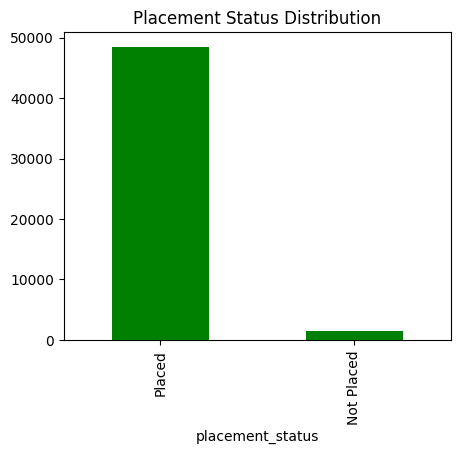

In [22]:
# 3. How many students are placed and not placed
placement_status_counts=df['placement_status'].value_counts()
print(placement_status_counts)

plt.figure(figsize=(5,4))
placement_status_counts.plot(kind="bar",  color="green")
plt.title("Placement Status Distribution")
plt.show()

destination_country
UK              4939
Finland         4935
South Africa    4906
Germany         4864
India           4838
Canada          4832
Russia          4826
USA             4805
UAE             4799
Ireland         4765
Name: count, dtype: int64


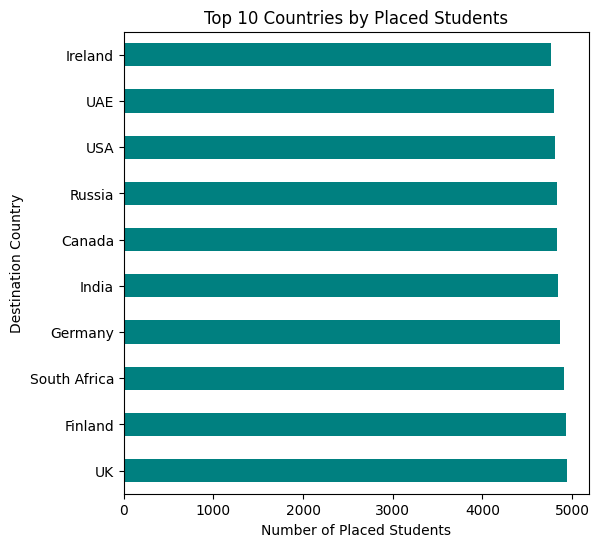

In [23]:
# 4. How many students are placed in each country

placed_by_country = df[df["placement_status"]=="Placed"]["destination_country"].value_counts()
print( placed_by_country.head(10))

placed_by_country.head(10).plot(kind="barh", figsize=(6,6), color="teal")
plt.title("Top 10 Countries by Placed Students")
plt.xlabel("Number of Placed Students")
plt.ylabel("Destination Country")
plt.show()


university_name
National University of Ireland Galway    1376
Novosibirsk State University              853
Saint Petersburg State University         834
Kazan Federal University                  767
University of Pretoria                    741
Name: count, dtype: int64


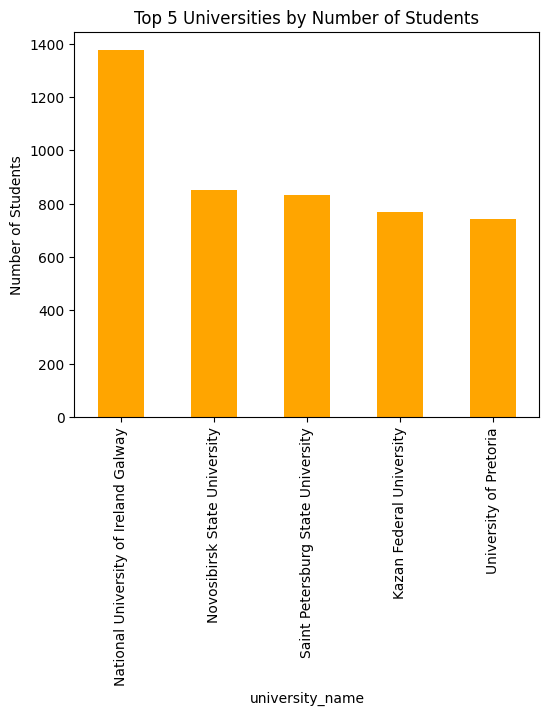

In [25]:
# 5. Top 5 universities (by number of students)

top_universities=df['university_name'].value_counts().head(5)
print(top_universities)
top_universities.plot(kind="bar", figsize=(6,5), color="orange")
plt.title("Top 5 Universities by Number of Students")
plt.ylabel("Number of Students")
plt.show()


Top 10 Companies by Average Salary:
 placement_company
Shell                 86110.566802
CVS Health            85493.284779
Nestle                85026.237331
Coca-Cola             84470.244048
Walmart               84303.384551
ExxonMobil            84079.343828
JPMorgan Chase        83995.496183
Berkshire Hathaway    83850.680385
Nvidia                83815.540033
Saudi Aramco          83587.172704
Name: starting_salary_usd, dtype: float64


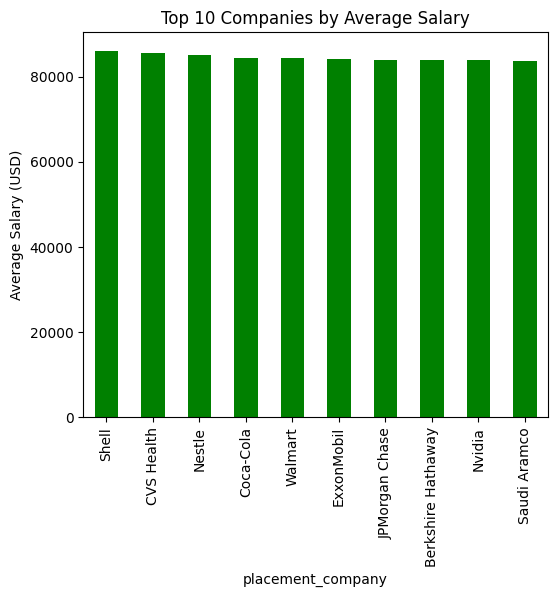

In [26]:
# 6.Companies with avg salary (Top 10)

avg_salary_company = (
    df[df["placement_status"]=="Placed"]
    .groupby("placement_company")["starting_salary_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 Companies by Average Salary:\n", avg_salary_company)

# Bar chart
avg_salary_company.plot(kind="bar", figsize=(6,5), color="green")
plt.title("Top 10 Companies by Average Salary")
plt.ylabel("Average Salary (USD)")
plt.show()



Yearly Admissions:
 year_of_enrollment
2014    4570
2015    4525
2016    4560
2017    4418
2018    4515
2019    5449
2020    5586
2021    5372
2022    5466
2023    5539
Name: count, dtype: int64


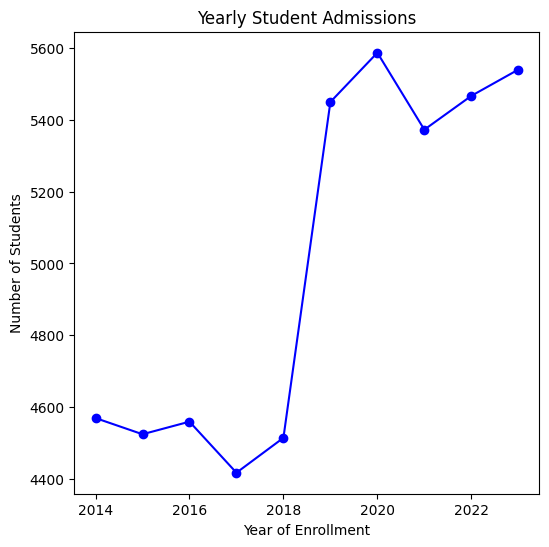

In [27]:
# 7. Yearly wise students admissions
yearly_admissions = df["year_of_enrollment"].value_counts().sort_index()
print("\nYearly Admissions:\n", yearly_admissions)

# Line chart
yearly_admissions.plot(kind="line", figsize=(6,6), marker="o", color="blue")
plt.title("Yearly Student Admissions")
plt.xlabel("Year of Enrollment")
plt.ylabel("Number of Students")
plt.show()


Students by Language Proficiency Test:
 language_proficiency_test
PTE         10041
IELTS       10024
Duolingo    10014
GRE          9975
TOEFL        9946
Name: count, dtype: int64


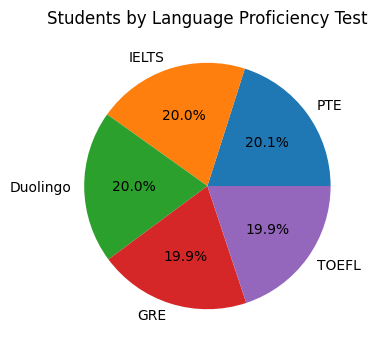

In [28]:
# 8.How many students are in each language proficiency test

language_test_counts = df["language_proficiency_test"].value_counts()
print("\nStudents by Language Proficiency Test:\n", language_test_counts)

# Pie chart
language_test_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6,4), ylabel="")
plt.title("Students by Language Proficiency Test")
plt.show()


education_type
Diploma          10906
Masters          10486
Graduation        9096
PhD               9002
Integrated PG     8855
Certificate       1655
Name: count, dtype: int64


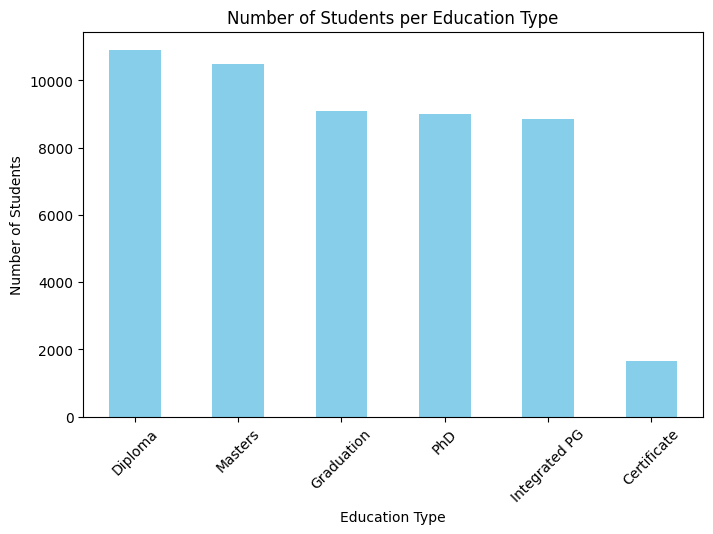

In [32]:
# 9. total students in education_type
education_count=df['education_type'].value_counts()
print(education_count)

plt.figure(figsize=(8,5))
education_count.plot(kind='bar', color='skyblue')
plt.title('Number of Students per Education Type')
plt.xlabel('Education Type')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.show()

In [33]:
df.to_sql("global_student_data", engine, if_exists="replace", index=False)

5